In [32]:
import os

import xarray as xr
import numpy as np

# %matplotlib widget
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
# TkAgg is usually built-in and very fast

import sys

%load_ext autoreload
%autoreload 1

sys.path.insert(0, '../../instrument/')
from Agilent.instr_N9928A import N9928A

sys.path.insert(0, '../../pattern/')
%aimport helper_sweep
from helper_sweep import do_sweep

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
_address = "10.0.100.110"
_instr = N9928A(_address)

Connected to N9928A [10.0.100.110:5025].


In [34]:
_instr.reference('EXT')
_instr.start_frequency(0.2e9)
_instr.stop_frequency(0.4e9)
_instr.if_frequency(1e3)
_instr.average(1, mode='sweep')
_instr.points(1001)
_instr.power(-10)

In [35]:
start_freq_list = np.arange(0.1, 2.1, 0.02) * 1e9

In [36]:
config_device = [_instr]
config_sweep = [
    [
        [_instr.power, 'power_dbm', np.array([-30, -15, 0])]
    ],
    [
        [_instr.start_frequency, 'start_frequency_hz', start_freq_list],
        [_instr.stop_frequency, 'stop_frequency_hz', start_freq_list + 0.02e9]
    ]
]

In [37]:
# config_device = [_instr]
# config_sweep = [
#     [
#         [_instr.power, 'power_dbm', np.arange(-5, 3+1e-9, 1)]
#     ]
# ]

In [38]:
file_path = os.path.join(os.getcwd(), 'boloq_low_1.zarr')
do_sweep(config_device, config_sweep, _instr.get_trace, file_path)

100%|██████████| 300/300 [25:27<00:00,  5.09s/it]


In [39]:
file_path = 'boloq_low_1.zarr'

with xr.open_zarr(file_path, consolidated=False) as f:
    raw_data = f['S21']

In [40]:
y_list = np.array([150, 170, 200, 250, 300])[::-1]
y0 = 10
alpha = 23.2
f_list = alpha/np.sqrt(y_list+y0)

print(f_list)

[1.31767146 1.43880292 1.6009521  1.7292259  1.83412104]


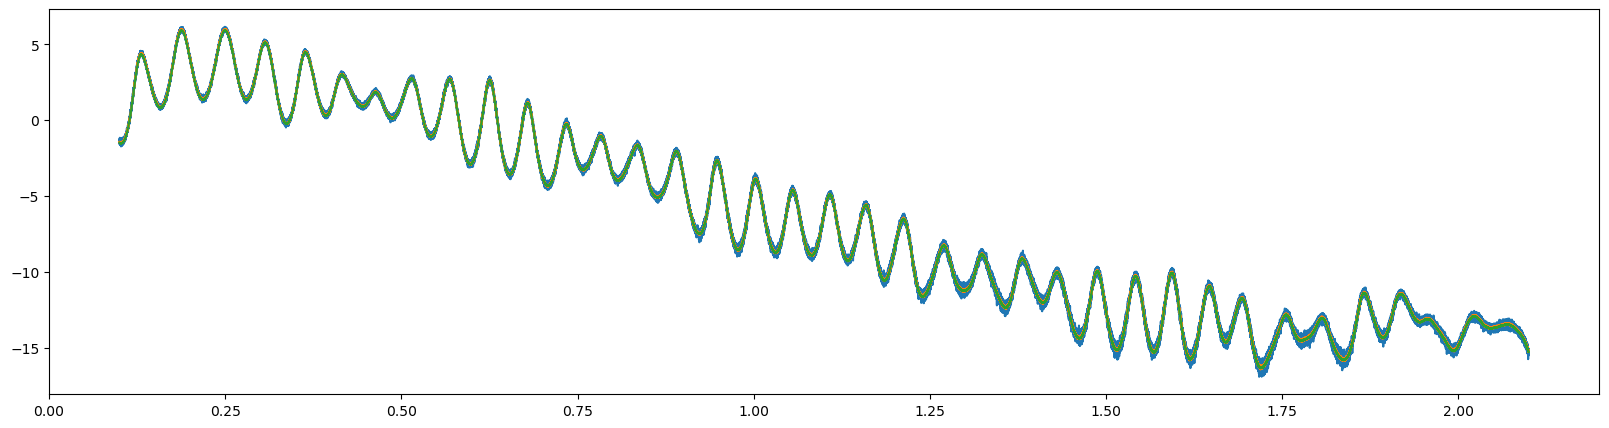

In [41]:
plt.figure(figsize = (20,5))

try:
    # plt.pcolormesh(raw_data.N9928A_frequency_hz/1e9, raw_data.N9928A_power_dbm, 20*np.log10(np.abs(raw_data).max(dim='N9928A_if_frequency_hz')).squeeze())
    # plt.colorbar()

    for _power in raw_data.N9928A_power_dbm:
        plt.plot(raw_data.N9928A_frequency_hz/1e9, 20*np.log10(np.abs(raw_data.sel(N9928A_power_dbm=_power).squeeze())))
except:
    plt.plot(raw_data.N9928A_frequency_hz/1e9, 20*np.log10(np.abs(raw_data.squeeze())))

# plt.vlines(f_list, -50, -10, color='k')

plt.show()

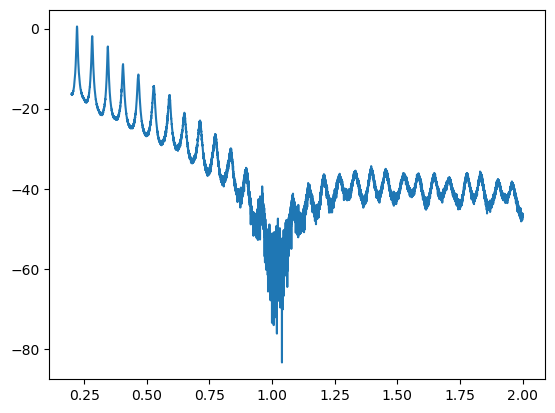

In [84]:
plt.figure()

plt.plot(raw_data.N9928A_frequency_hz/1e9, 20*np.log10(np.abs(raw_data.sel(N9928A_power_dbm=-10).squeeze())))

# plt.vlines(f_list, -50, -10, color='k')

plt.show()